In [1]:
import sys
sys.path.append('./lib')
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
import plotlib as plib

In [2]:
xlabel= "case" #label for the different cases 
cases = ["baseline_0.7","baseline_inter","baseline_union","medium_0.7", "medium_inter", "medium_union", "high_0.7", "high_inter", "high_union"] #different scenarios you want to plot on x axis
subcases = ["o0", "1bts", "adapt."] #different scenarios you want to plot for each point of x
colors = ["blue", "darkorange", "red"] #colors of each subcase 
kw_save= "skycomplx_mask_vs_fittingscheme" #name to save the pdf
offset = 0.05 #size of the offset between the different subcases
path = "./"

In [3]:
mom = ['Aw1b', 'w1bw1b', 'Aw1t', 'w1bw1t', 'w1tw1t', 'Asw1bs', 'w1bsw1bs', 'Asw1b', 'Asw1t', 'Aw1bs', 'w1bw1bs', 'w1tw1bs']
def nfixmom(res):
    total = 0   
    zero_counts_mean = {}
    for k in mom:
        arr = np.asarray(res[k])
        total += len(arr[:,1])
        means = np.mean(arr, axis=1)
        zero_counts_mean[k] = np.sum(means == 0)
    total_zero_means = total-sum(zero_counts_mean.values())
    return total_zero_means

In [4]:
#load the results (for the moment, I keep it very explicit, as it's hard to be general with so many keywords!):

# res_c%(casenumber)_sc%(subcasenumber):
res_c0sc0 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('b','b',0.7,'0',0),allow_pickle=True).item()
res_c0sc1 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('b','b',0.7,'1bts',1),allow_pickle=True).item()
res_c0sc2 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s_adaptative.npy'%('b','b',0.7,'1bts',1),allow_pickle=True).item()

res_c1sc0 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('b','b','intersection_scaleSmooth1','0',0),allow_pickle=True).item()
res_c1sc1 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('b','b','intersection_scaleSmooth1','1bts',1),allow_pickle=True).item()
res_c1sc2 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s_adaptative.npy'%('b','b','intersection_scaleSmooth1','1bts',1),allow_pickle=True).item()

res_c2sc0 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('b','b','union_scaleSmooth1','0',0),allow_pickle=True).item()
res_c2sc1 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('b','b','union_scaleSmooth1','1bts',1),allow_pickle=True).item()
res_c2sc2 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s_adaptative.npy'%('b','b','union_scaleSmooth1','1bts',1),allow_pickle=True).item()

res_c3sc0 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('m','m',0.7,'0',0),allow_pickle=True).item()
res_c3sc1 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('m','m',0.7,'1bts',1),allow_pickle=True).item()
res_c3sc2 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s_adaptative.npy'%('m','m',0.7,'1bts',1),allow_pickle=True).item()

res_c4sc0 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('m','m','intersection_scaleSmooth1','0',0),allow_pickle=True).item()
res_c4sc1 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('m','m','intersection_scaleSmooth1','1bts',1),allow_pickle=True).item()
res_c4sc2 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s_adaptative.npy'%('m','m','intersection_scaleSmooth1','1bts',1),allow_pickle=True).item()

res_c5sc0 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('m','m','union_scaleSmooth1','0',0),allow_pickle=True).item()
res_c5sc1 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('m','m','union_scaleSmooth1','1bts',1),allow_pickle=True).item()
res_c5sc2 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s_adaptative.npy'%('m','m','union_scaleSmooth1','1bts',1),allow_pickle=True).item()

res_c6sc0 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('h','h',0.7,'0',0),allow_pickle=True).item()
res_c6sc1 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('h','h',0.7,'1bts',1),allow_pickle=True).item()
res_c6sc2 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s_adaptative.npy'%('h','h',0.7,'1bts',1),allow_pickle=True).item()

res_c7sc0 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('h','h','intersection_scaleSmooth1','0',0),allow_pickle=True).item()
res_c7sc1 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('h','h','intersection_scaleSmooth1','1bts',1),allow_pickle=True).item()
res_c7sc2 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s_adaptative.npy'%('h','h','intersection_scaleSmooth1','1bts',1),allow_pickle=True).item()

res_c8sc0 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('h','h','union_scaleSmooth1','0',0),allow_pickle=True).item()
res_c8sc1 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s.npy'%('h','h','union_scaleSmooth1','1bts',1),allow_pickle=True).item()
res_c8sc2 = np.load(path + 'best_fits/results_d%ss%s_%s_Nmt-fg_gaussbeam_bandpass_ds_o%s_fix%s_adaptative.npy'%('h','h','union_scaleSmooth1','1bts',1),allow_pickle=True).item()

res_list = [
    [res_c0sc0, res_c1sc0, res_c2sc0, res_c3sc0, res_c4sc0, res_c5sc0, res_c6sc0, res_c7sc0, res_c8sc0], # all cases ordered for subcase 0
    [res_c0sc1, res_c1sc1, res_c2sc1, res_c3sc1, res_c4sc1, res_c5sc1, res_c6sc1, res_c7sc1, res_c8sc1], # all cases ordered for subcase 1
    [res_c0sc2, res_c1sc2, res_c2sc2, res_c3sc2, res_c4sc2, res_c5sc2, res_c6sc2, res_c7sc2, res_c8sc2]  # all cases ordered for subcase 2
    # up to subcase N !
]

#load BmodeLike resuts (for the moment, I keep it very explicit, as it's hard to be general with so many keywords!):

# bmodelike_c%(casenumber)_sc%(subcasenumber):
bmodelike_c0sc0 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('baseline',0.7,'0','baseline',0.7,'0'))
bmodelike_c0sc1 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('baseline',0.7,'1bts','baseline',0.7,'1bts'))
bmodelike_c0sc2 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('baseline',0.7,'1bts_adaptative','baseline',0.7,'1bts_adaptative'))

bmodelike_c1sc0 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('baseline','intersection_scaleSmooth1','0','baseline','intersection_scaleSmooth1','0'))
bmodelike_c1sc1 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('baseline','intersection_scaleSmooth1','1bts','baseline','intersection_scaleSmooth1','1bts'))
bmodelike_c1sc2 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('baseline','intersection_scaleSmooth1','1bts_adaptative','baseline','intersection_scaleSmooth1','1bts_adaptative'))

bmodelike_c2sc0 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('baseline','union_scaleSmooth1','0','baseline','union_scaleSmooth1','0'))
bmodelike_c2sc1 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('baseline','union_scaleSmooth1','1bts','baseline','union_scaleSmooth1','1bts'))
bmodelike_c2sc2 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('baseline','union_scaleSmooth1','1bts_adaptative','baseline','union_scaleSmooth1','1bts_adaptative'))

bmodelike_c3sc0 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('medium_complexity',0.7,'0','medium_complexity',0.7,'0'))
bmodelike_c3sc1 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('medium_complexity',0.7,'1bts','medium_complexity',0.7,'1bts'))
bmodelike_c3sc2 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('medium_complexity',0.7,'1bts_adaptative','medium_complexity',0.7,'1bts_adaptative'))

bmodelike_c4sc0 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('medium_complexity','intersection_scaleSmooth1','0','medium_complexity','intersection_scaleSmooth1','0'))
bmodelike_c4sc1 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('medium_complexity','intersection_scaleSmooth1','1bts','medium_complexity','intersection_scaleSmooth1','1bts'))
bmodelike_c4sc2 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('medium_complexity','intersection_scaleSmooth1','1bts_adaptative','medium_complexity','intersection_scaleSmooth1','1bts_adaptative'))

bmodelike_c5sc0 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('medium_complexity','union_scaleSmooth1','0','medium_complexity','union_scaleSmooth1','0'))
bmodelike_c5sc1 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('medium_complexity','union_scaleSmooth1','1bts','medium_complexity','union_scaleSmooth1','1bts'))
bmodelike_c5sc2 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('medium_complexity','union_scaleSmooth1','1bts_adaptative','medium_complexity','union_scaleSmooth1','1bts_adaptative'))

bmodelike_c6sc0 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('high_complexity',0.7,'0','high_complexity',0.7,'0'))
bmodelike_c6sc1 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('high_complexity',0.7,'1bts','high_complexity',0.7,'1bts'))
bmodelike_c6sc2 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('high_complexity',0.7,'1bts_adaptative','high_complexity',0.7,'1bts_adaptative'))

bmodelike_c7sc0 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('high_complexity','intersection_scaleSmooth1','0','high_complexity','intersection_scaleSmooth1','0'))
bmodelike_c7sc1 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('high_complexity','intersection_scaleSmooth1','1bts','high_complexity','intersection_scaleSmooth1','1bts'))
bmodelike_c7sc2 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('high_complexity','intersection_scaleSmooth1','1bts_adaptative','high_complexity','intersection_scaleSmooth1','1bts_adaptative'))

bmodelike_c8sc0 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('high_complexity','union_scaleSmooth1','0','high_complexity','union_scaleSmooth1','0'))
bmodelike_c8sc1 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('high_complexity','union_scaleSmooth1','1bts','high_complexity','union_scaleSmooth1','1bts'))
bmodelike_c8sc2 = np.loadtxt(path + '../BmodeLike/outputs/moments_%s_%s_Nmt-fg_o%s/bounds/moments_%s_%s_Nmt-fg_o%s_bounds.txt'%('high_complexity','union_scaleSmooth1','1bts_adaptative','high_complexity','union_scaleSmooth1','1bts_adaptative'))

bmodelike_list = [
    [bmodelike_c0sc0, bmodelike_c1sc0, bmodelike_c2sc0, bmodelike_c3sc0, bmodelike_c4sc0, bmodelike_c5sc0, bmodelike_c6sc0, bmodelike_c7sc0, bmodelike_c8sc0], # all cases ordered for subcase 0
    [bmodelike_c0sc1, bmodelike_c1sc1, bmodelike_c2sc1, bmodelike_c3sc1, bmodelike_c4sc1, bmodelike_c5sc1, bmodelike_c6sc1, bmodelike_c7sc1, bmodelike_c8sc1], # all cases ordered for subcase 1
    [bmodelike_c0sc2, bmodelike_c1sc2, bmodelike_c2sc2, bmodelike_c3sc2, bmodelike_c4sc2, bmodelike_c5sc2, bmodelike_c6sc2, bmodelike_c7sc2, bmodelike_c8sc2]  # all cases ordered for subcase 2
    # up to subcase N !
]

In [5]:
bias_all, lower_all, upper_all = [], [], []
X_all, sigma_X_all = [], []

for res_group in res_list:
    X_group, sigma_X_group = [], []
    for res in res_group:
        Xmean, Xstd = plib.getX2_analytical(res, Nmin=0, Nmax=20)
        X_group.append(Xmean)
        sigma_X_group.append(Xstd)
    X_all.append(np.array(X_group))
    sigma_X_all.append(np.array(sigma_X_group))

for res_group in bmodelike_list:
    bias_group, lower_group, upper_group = [], [], []
    for res in res_group:
        bias, lower, upper = res[4:7]
        bias_group.append(bias)
        lower_group.append(lower)
        upper_group.append(upper)
    bias_all.append(np.array(bias_group))
    lower_all.append(np.array(lower_group))
    upper_all.append(np.array(upper_group))

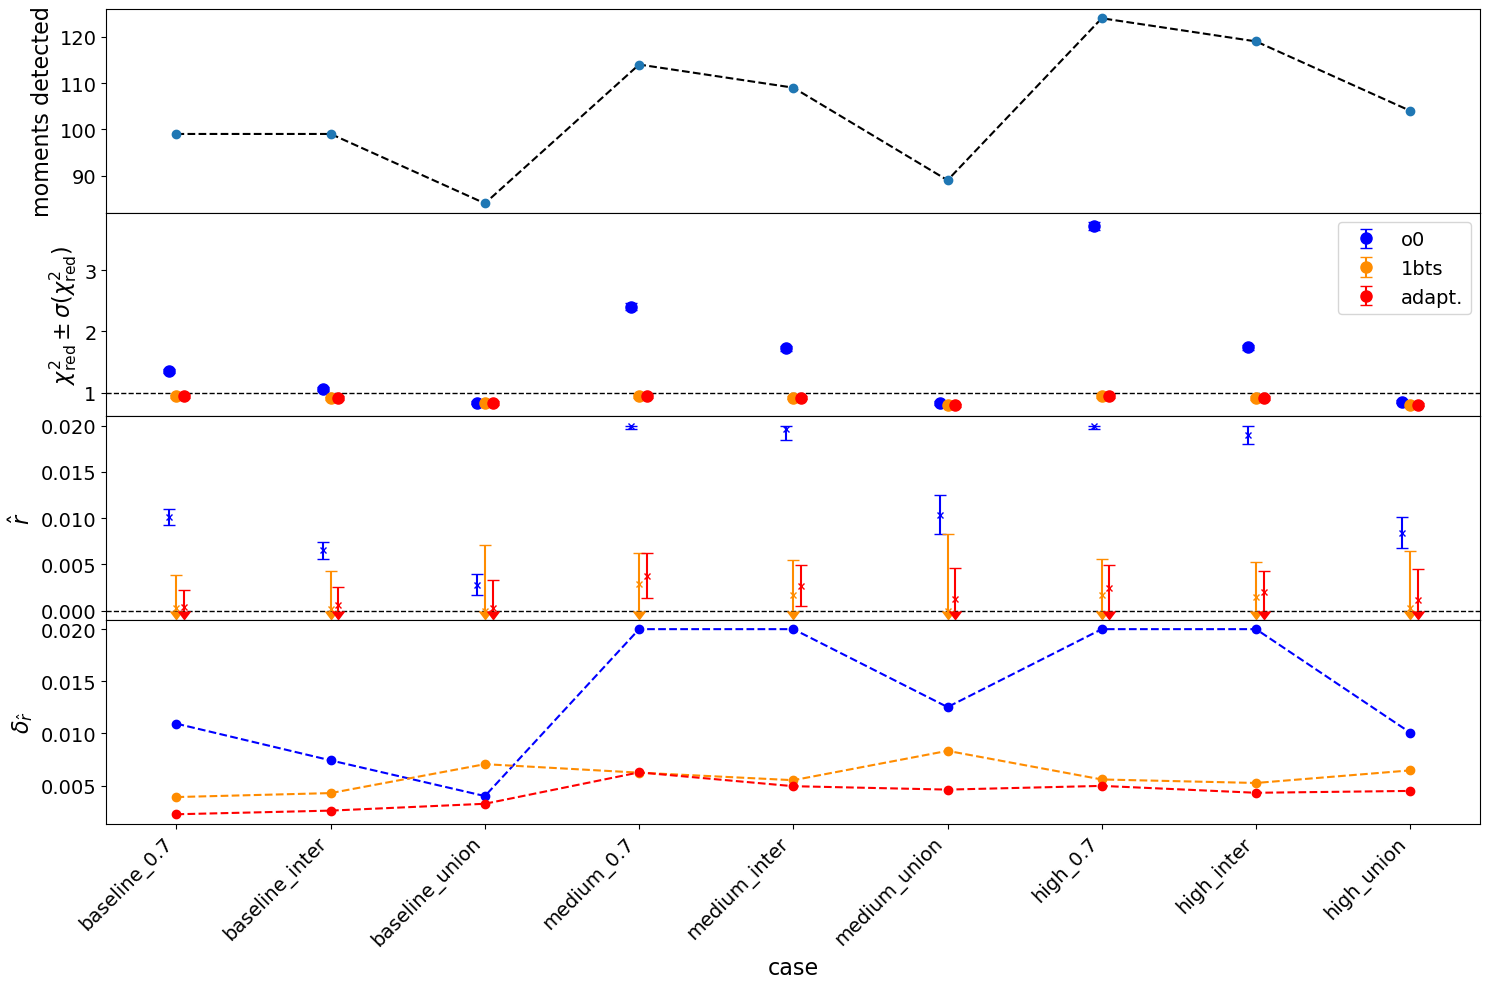

In [6]:
x = np.arange(len(cases))

fig, (ax1, ax2,ax3,ax4) = plt.subplots(4, 1, figsize=(15, 10), sharex=True, gridspec_kw={'hspace': 0.0})
ax2.axhline(1, linestyle="--", color="k", linewidth=1)
ax3.axhline(0, linestyle="--", color="k", linewidth=1)

# Plot des erreurs
for i in range(len(res_list)):
    ax2.errorbar(x + (i-1)*offset, X_all[i], yerr=sigma_X_all[i], fmt="o", label=subcases[i],
                 c=colors[i], markersize=8, capsize=4)
    ax3.errorbar(x + (i-1)*offset, upper_all[i], yerr=[upper_all[i]-lower_all[i], np.zeros(len(cases))], uplims=~np.bool(lower_all[i]), fmt="o", label=subcases[i],
                 c=colors[i], markersize=0, capsize=4)
    ax3.plot(x + (i-1)*offset, bias_all[i], marker="x", linestyle='', c=colors[i], markersize=5)
    ax4.plot(x, upper_all[i], label=subcases[i], c=colors[i],linestyle='--')
    ax4.plot(x, upper_all[i], marker="o", label=subcases[i],linestyle='',c=colors[i])

ax1.plot(x, [nfixmom(res) for res in res_list[i]], label=subcases[i], c='k',linestyle='--')
ax1.plot(x, [nfixmom(res) for res in res_list[i]], marker="o", label=subcases[i],linestyle='')
ax1.set_ylabel(r"moments detected", fontsize=16)
ax1.tick_params(labelsize=14)
ax2.set_ylabel(r"$\chi^2_{\rm red} \pm \sigma(\chi^2_{\rm red})$", fontsize=16)
ax2.legend(fontsize=14)
ax2.tick_params(labelsize=14)
ax3.set_xticks(x)
ax3.set_ylabel(r"$\hat{r}$", fontsize=16)
ax3.tick_params(labelsize=14)
ax4.set_xticklabels(cases, fontsize=14, rotation=45, ha="right")
ax4.set_ylabel(r"$\delta_{\hat{r}}$", fontsize=16)
ax4.tick_params(labelsize=14)
plt.xlabel("%s" % xlabel, fontsize=16)
plt.tight_layout()
plt.savefig(f"./pdf_plots/sigma_r_{kw_save}.pdf", bbox_inches="tight")
plt.show()